In [ ]:
import pandas as pd
import numpy as np
from glob import glob
import os

In [ ]:
ROOT_STATS_DIR = "./stats_permute_attack_success"

paths_dict = {}
for directory in os.listdir(ROOT_STATS_DIR):
    if directory.startswith("results_"):
        exp_name = directory.split("_")[1:]
        exp_name = "_".join(exp_name)
        exp_csvs = glob(os.path.join(ROOT_STATS_DIR, directory, "*.csv"))
        correct_csv_path = filter(lambda p: "correct" in p, exp_csvs)
        incorrect_csv_path = filter(lambda p: "incorrect" in p, exp_csvs)
        paths_dict[exp_name] = {
            "correct": list(correct_csv_path)[0],
            "incorrect": list(incorrect_csv_path)[0],
        }

In [ ]:
LABEL_VALUE_MAP = {"correct": 0, "incorrect": 1}
example_df_correct = pd.read_csv(list(paths_dict.values())[1]["correct"])
example_df_incorrect = pd.read_csv(list(paths_dict.values())[1]["incorrect"])
# add label column to both dataframes
example_df_correct["label"] = LABEL_VALUE_MAP["correct"]
example_df_incorrect["label"] = LABEL_VALUE_MAP["incorrect"]
# concatenate both dataframes
example_df = pd.concat([example_df_correct, example_df_incorrect])

In [ ]:
example_df.head()

In [ ]:
example_df["label"].value_counts()

In [ ]:
from sklearn.preprocessing import RobustScaler

x = example_df.drop(columns=["label"])
y = example_df["label"]

scaler = RobustScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled.head()

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
# Calculate mutual information scores
mutual_info_scores = mutual_info_classif(x_scaled, y, random_state=42)

# Create a series for easy plotting
mutual_info_series = pd.Series(mutual_info_scores, index=x.columns)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=mutual_info_series.sort_values(ascending=False), y=mutual_info_series.sort_values(ascending=False).index)
plt.title('Mutual Information Scores')
plt.xlabel('MI Score')
plt.ylabel('Features')
plt.show()

In [ ]:
from dataclasses import dataclass


LABEL_VALUE_MAP = {"correct": 0, "incorrect": 1}

@dataclass
class ResultsCSVPreprocessor:
    csv_path_correct: str
    csv_path_incorrect: str
    label_value_map: dict = None
    scaler: object = None

    def _combine_dataframes(self):
        df_correct = pd.read_csv(self.csv_path_correct)
        df_incorrect = pd.read_csv(self.csv_path_incorrect)
        if self.label_value_map:
            df_correct["label"] = self.label_value_map.get("correct", 0)
            df_incorrect["label"] = self.label_value_map.get("incorrect", 1)
        combined_df = pd.concat([df_correct, df_incorrect])
        # drop median column
        if "median" in combined_df.columns:
            combined_df = combined_df.drop(columns=["values_above_p99", "vals_below_low_negative_threshold_4th_percentile", "vals_below_low_negative_threshold"])
        return combined_df
    
    def _scale_features(self, df):
        x = df.drop(columns=["label"])
        if self.scaler is None:
            self.scaler = RobustScaler()
            x_scaled = self.scaler.fit_transform(x)
        else:
            x_scaled = self.scaler.transform(x)
        x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
        x_scaled_df["label"] = df["label"].values
        return x_scaled_df
    
    def _rename_columns(self, df):
        rename_map ={
            "mean": "Mean",
            "kurt" : "Kurtosis",
            "median": "Median",
            "std_dev": "Std. Dev.",
            "skewness": "Skewness",
            "p99_value": "99th percentile",
            "vals_over_high_positive_threshold_4th_percentile": "No. values > 0.75",
            "vals_below_low_negative_threshold_4th_percentile": "No. values < -0.75",
            "vals_over_high_positive_threshold": "No. values > 0.9",
            "vals_below_low_negative_threshold": "No. values < -0.9",
        }
        df = df.rename(columns=rename_map)
        return df
    def prepare_features_and_labels(self):
        combined_df = self._combine_dataframes()
        scaled_df = self._scale_features(combined_df)
        scaled_df = self._rename_columns(scaled_df)
        return scaled_df.drop(columns=["label"]), scaled_df["label"]


In [ ]:
FONTSIZE = 20


In [ ]:
class PredictivePowerAnalyzer:
    def __init__(self, x: pd.DataFrame, y: pd.Series):
        self.x = x
        self.y = y

    def compute_mutual_info(self):
        from sklearn.feature_selection import mutual_info_classif

        self.mutual_info_scores = mutual_info_classif(self.x, self.y, random_state=42)
        self.mutual_info_series = pd.Series(self.mutual_info_scores, index=self.x.columns)
        return self.mutual_info_series

    def compute_f_test(self):
        from sklearn.feature_selection import f_classif

        self.f_test_scores, self.f_test_pvalues = f_classif(self.x, self.y)
        self.f_test_series = pd.Series(self.f_test_scores, index=self.x.columns)
        self.f_test_pvalues_series = pd.Series(self.f_test_pvalues, index=self.x.columns)
        return self.f_test_series, self.f_test_pvalues_series
    
    def plot_mutual_info(self):
        """
        Plots the mutual information scores.
        """
        import matplotlib.pyplot as plt
        import seaborn as sns
        from matplotlib.ticker import FuncFormatter

        # Define fontsize if not globally defined

        def custom_formatter(x, pos):
            """
            Formats the tick label dynamically:
            - 0 -> "0"
            - 0.500 -> "0.5"
            - 0.125 -> "0.125"
            """
            if x == 0:
                return "0"
            # Format to 6 decimal places, then strip trailing zeros and the decimal point if needed
            return f'{x:.6f}'.rstrip('0').rstrip('.')

        if not hasattr(self, 'mutual_info_series'):
            raise ValueError("Mutual information scores not computed. Call compute_mutual_info() first.")

        self.fig = plt.figure(figsize=(20, 10))
        
        # Sort the data for better visualization
        sorted_mi = self.mutual_info_series.sort_values(ascending=False)
        
        sns.barplot(x=sorted_mi, y=sorted_mi.index)
        
        plt.xlabel('MI Score', fontsize=FONTSIZE)
        plt.ylabel('')
        
        # Apply the dynamic formatter to the x-axis
        plt.gca().xaxis.set_major_formatter(FuncFormatter(custom_formatter))

        plt.xticks(fontsize=FONTSIZE)
        plt.yticks(fontsize=FONTSIZE)
        
        plt.tight_layout() # Adjusts layout to prevent label cutoff
        plt.show()

    def save_mutual_info_plot(self, filepath: str):
        if not hasattr(self, 'fig'):
            raise ValueError("No plot available. Call plot_mutual_info() first.")
        self.fig.savefig(filepath, bbox_inches='tight') 
    
    def plot_f_test(self):
        import matplotlib.pyplot as plt
        import seaborn as sns

        if not hasattr(self, 'f_test_series'):
            raise ValueError("F-test scores not computed. Call compute_f_test() first.")

        plt.figure(figsize=(12, 8))
        sns.barplot(x=self.f_test_series.sort_values(ascending=False), y=self.f_test_series.sort_values(ascending=False).index)
        # on each bar, add p-value as text
        for i, feature in enumerate(self.f_test_series.sort_values(ascending=False).index):
            p_value = self.f_test_pvalues_series[feature]
            plt.text(self.f_test_series[feature], i, f'p={p_value:.3e}', va='center')
        plt.title('F-test Scores')
        plt.xlabel('F-test Score')
        plt.ylabel('Features')
        plt.show()

In [ ]:
import pandas as pd
import numpy as np
from dataclasses import dataclass

@dataclass
class XGBoostAnalyzer:
    """
    A class to train an XGBoost classifier, evaluate it using stratified
    cross-validation, and visualize feature importances.
    """
    x: pd.DataFrame
    y: pd.Series
    model: object = None

    def train_model(self):
        """
        Performs stratified 10-fold cross-validation and then trains a final
        XGBoost model on the entire dataset.
        """
        from xgboost import XGBClassifier
        from sklearn.model_selection import StratifiedKFold
        from sklearn.metrics import accuracy_score
        # Suppress warnings from XGBoost
        import warnings
        warnings.filterwarnings("ignore", category=UserWarning)
        # Initialize Stratified K-Fold
        n_splits = 10
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        fold_accuracies = []

        print(f"--- Starting Stratified {n_splits}-Fold Cross-Validation ---")

        # Loop through each fold
        for fold, (train_index, val_index) in enumerate(skf.split(self.x, self.y)):
            # Split the data for the current fold
            x_train, x_val = self.x.iloc[train_index], self.x.iloc[val_index]
            y_train, y_val = self.y.iloc[train_index], self.y.iloc[val_index]

            # Initialize and train the model for the fold
            fold_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
            fold_model.fit(x_train, y_train)

            # Make predictions and calculate accuracy
            y_pred = fold_model.predict(x_val)
            accuracy = accuracy_score(y_val, y_pred)
            fold_accuracies.append(accuracy)
            print(f"Fold {fold + 1}/{n_splits} Accuracy: {accuracy:.4f}")
        self.fold_accuracies = fold_accuracies
        # Print the summary of cross-validation
        print("\n--- Cross-Validation Summary ---")
        print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
        
        # Train the final model on the entire dataset
        print("\n--- Training Final Model on All Data ---")
        self.model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        self.model.fit(self.x, self.y)
        print("Final model has been trained and is stored in self.model.")
        
        return self.model

    def plot_feature_importances(self):
        """
        Plots the feature importances from the trained XGBoost model.
        """
        import matplotlib.pyplot as plt
        import seaborn as sns
        from matplotlib.ticker import FuncFormatter

        # Define fontsize if not globally defined

        def custom_formatter(x, pos):
            """
            Formats the tick label dynamically:
            - 0 -> "0"
            - 0.500 -> "0.5"
            - 0.125 -> "0.125"
            """
            if x == 0:
                return "0"
            
            # 1. Format to a fixed high precision (e.g., 6 decimals)
            # 2. rstrip('0') removes trailing zeros
            # 3. rstrip('.') removes the decimal point if the number is an integer
            return f'{x:.6f}'.rstrip('0').rstrip('.')

        if self.model is None:
            raise ValueError("Model not trained. Please call train_model() first.")
        
        # Create a pandas Series for easy plotting
        feature_importances = pd.Series(self.model.feature_importances_, index=self.x.columns)
        
        self.fig = plt.figure(figsize=(20, 10))
        
        # Sort values for the plot
        sorted_importances = feature_importances.sort_values(ascending=False)
        
        sns.barplot(
            x=sorted_importances, 
            y=sorted_importances.index
        )
        
        plt.xlabel('Importance Score', fontsize=FONTSIZE)
        plt.ylabel('') 
        
        # Apply the custom formatter to the X-axis
        plt.gca().xaxis.set_major_formatter(FuncFormatter(custom_formatter))
        
        # Set y and x ticks fontsize
        plt.yticks(fontsize=FONTSIZE)
        plt.xticks(fontsize=FONTSIZE)
        
        plt.tight_layout()
        plt.show()

    def save_feature_importances_plot(self, filepath: str):
        """Saves the feature importances plot to a file."""
        if not hasattr(self, 'fig'):
            raise ValueError("No plot available. Call plot_feature_importances() first.")
        
        # The tight_layout() from the plot method will apply here too.
        # Alternatively, for a more robust save, you could use bbox_inches='tight'.
        self.fig.savefig(filepath, bbox_inches='tight') # <-- MODIFIED: Added bbox_inches
    
    def save_fold_accuracies(self, filepath: str):
        """Saves the fold accuracies to a CSV file."""
        if not hasattr(self, 'fold_accuracies'):
            raise ValueError("Fold accuracies not available. Ensure train_model() has been called.")
        accuracies_df = pd.DataFrame({
            'Fold': list(range(1, len(self.fold_accuracies) + 1)),
            'Accuracy': self.fold_accuracies
        })
        accuracies_df.to_csv(filepath, index=False)

In [ ]:
root_save_dir="./importance_analysis_attack_success"
os.makedirs(root_save_dir, exist_ok=True)
for exp_name, paths in paths_dict.items():
    print(f"Processing experiment: {exp_name}")
    preprocessor = ResultsCSVPreprocessor(
        csv_path_correct=paths["correct"],
        csv_path_incorrect=paths["incorrect"],
        label_value_map=LABEL_VALUE_MAP
    )
    x, y = preprocessor.prepare_features_and_labels()
    
    analyzer = PredictivePowerAnalyzer(x, y)
    mi_scores = analyzer.compute_mutual_info()
    analyzer.plot_mutual_info()
    mi_plot_path = os.path.join(root_save_dir, "plots", f"{exp_name}_mutual_info.pdf")
    os.makedirs(os.path.dirname(mi_plot_path), exist_ok=True)
    analyzer.save_mutual_info_plot(mi_plot_path)
    
    # xgb = XGBoostAnalyzer(x, y)
    # xgb.train_model()
    # xgb.plot_feature_importances()
    # fi_plot_path = os.path.join(root_save_dir, "plots", f"{exp_name}_feature_importances_xgb.pdf")
    # fold_accuracies_path = os.path.join(root_save_dir, "csv", f"{exp_name}_xgb_accuracies.csv")
    # os.makedirs(os.path.dirname(fold_accuracies_path), exist_ok=True)
    # xgb.save_fold_accuracies(fold_accuracies_path)
    # xgb.save_feature_importances_plot(fi_plot_path)

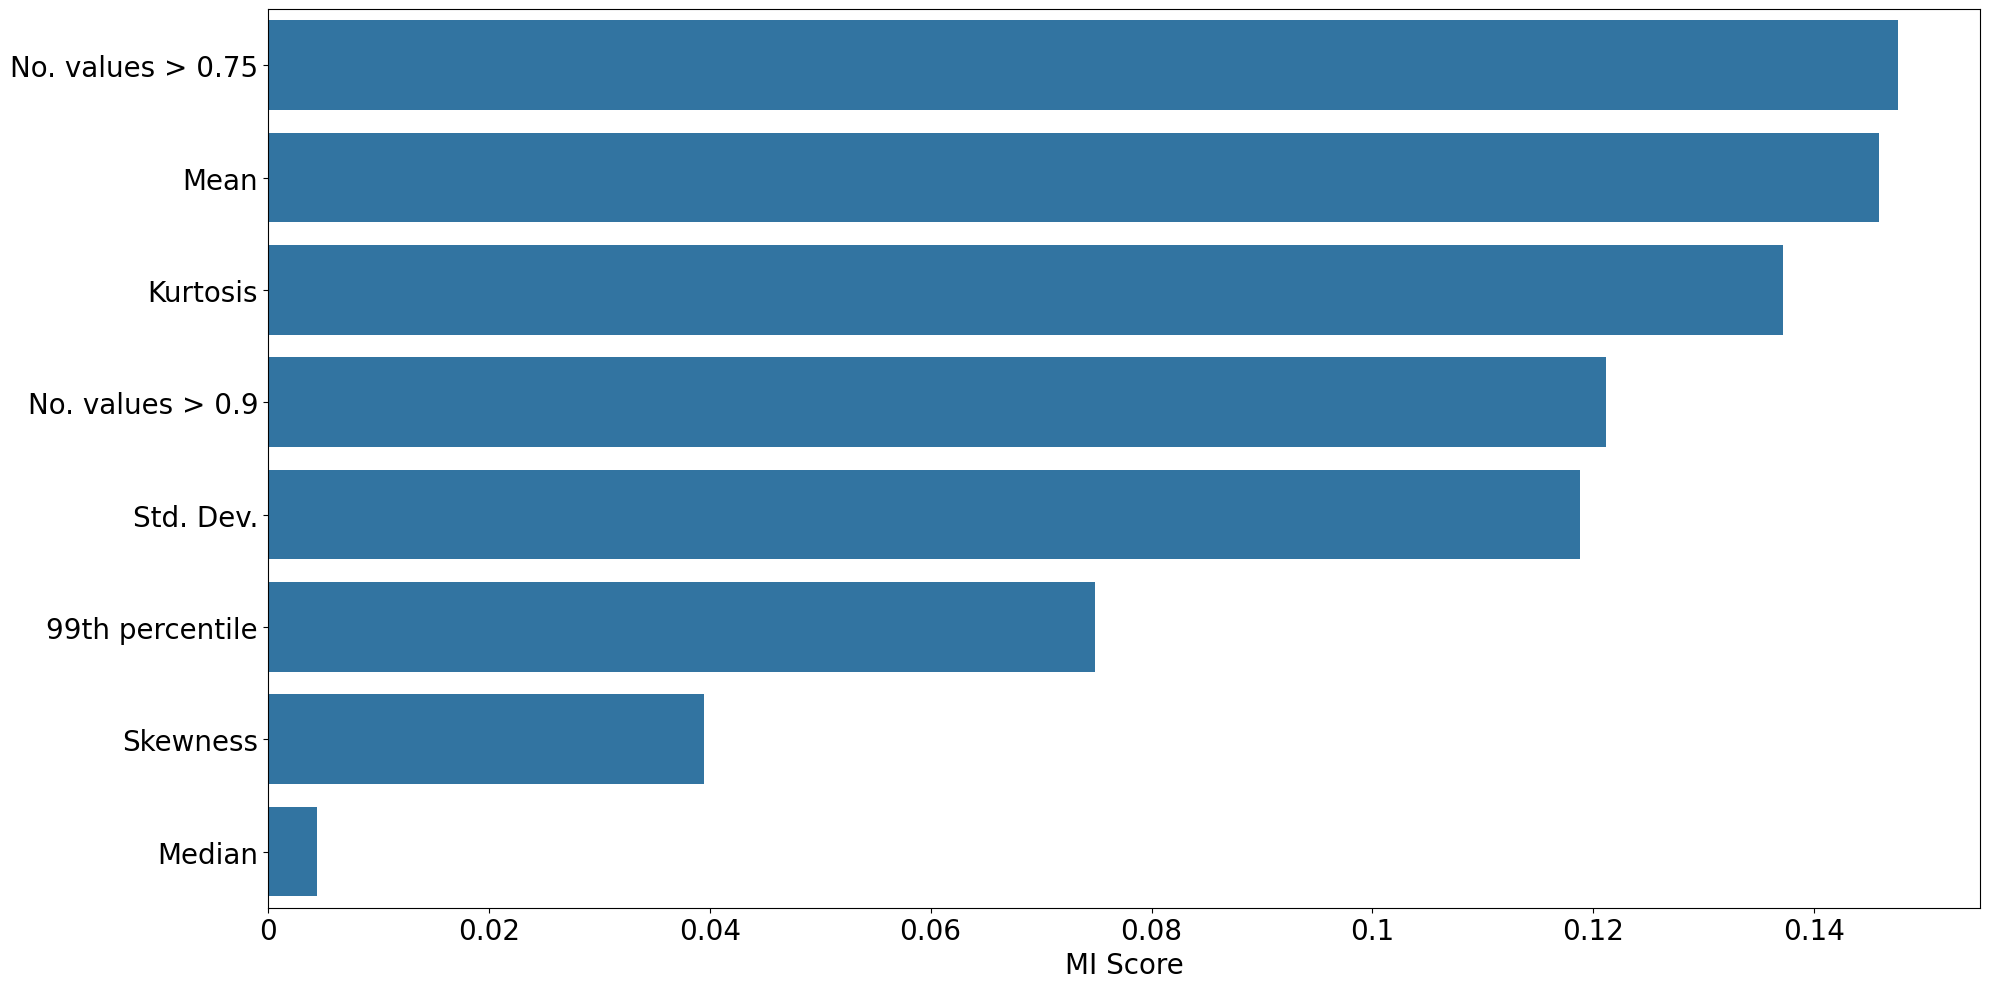

--- Starting Stratified 10-Fold Cross-Validation ---
Fold 1/10 Accuracy: 0.8121
Fold 2/10 Accuracy: 0.8029
Fold 3/10 Accuracy: 0.8056
Fold 4/10 Accuracy: 0.8121
Fold 5/10 Accuracy: 0.8027
Fold 6/10 Accuracy: 0.8133
Fold 7/10 Accuracy: 0.7949
Fold 8/10 Accuracy: 0.8186
Fold 9/10 Accuracy: 0.8047
Fold 10/10 Accuracy: 0.8143

--- Cross-Validation Summary ---
Average Accuracy: 0.8081 (+/- 0.0067)

--- Training Final Model on All Data ---
Final model has been trained and is stored in self.model.


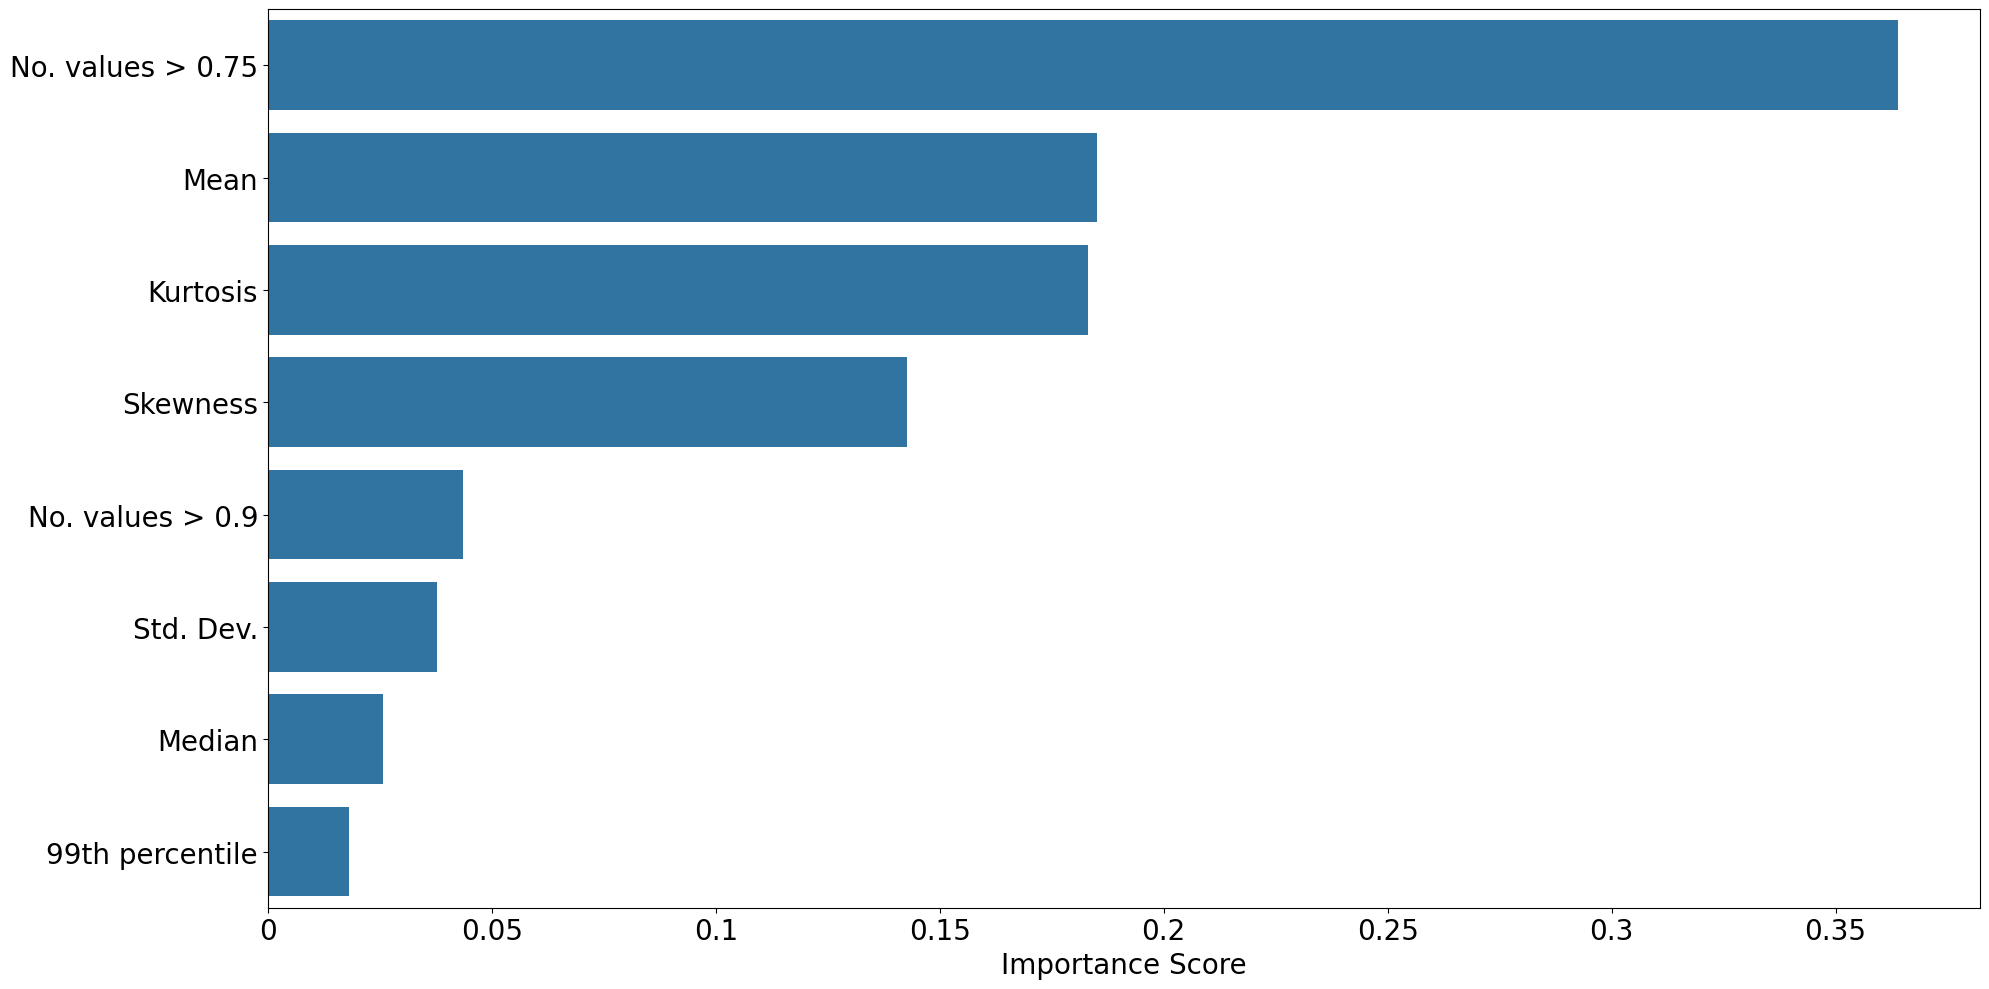

In [17]:
# now concatenate all dataframes and do the analysis on the full dataset
dfs= []
for exp_name, paths in paths_dict.items():
    preprocessor = ResultsCSVPreprocessor(
        csv_path_correct=paths["correct"],
        csv_path_incorrect=paths["incorrect"],
        label_value_map=LABEL_VALUE_MAP
    )
    df_combined = preprocessor._combine_dataframes()
    dfs.append(df_combined)

full_df = pd.concat(dfs)
scaled_df = preprocessor._scale_features(full_df)
scaled_df = preprocessor._rename_columns(scaled_df)
x_full = scaled_df.drop(columns=["label"])
y_full = scaled_df["label"]
analyzer = PredictivePowerAnalyzer(x_full, y_full)
mi_scores = analyzer.compute_mutual_info()
analyzer.plot_mutual_info()
mi_plot_path = os.path.join(root_save_dir, "plots", f"full_dataset_mutual_info.pdf")
analyzer.save_mutual_info_plot(mi_plot_path)
xgb = XGBoostAnalyzer(x_full, y_full)
xgb.train_model()
xgb.plot_feature_importances()
xgb.save_fold_accuracies(os.path.join(root_save_dir, "csv", f"full_dataset_xgb_accuracies.csv"))
xgb.save_feature_importances_plot(os.path.join(root_save_dir, "plots", f"full_dataset_feature_importances_xgb.pdf"))